### Library

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

### Read File

In [234]:
df = pd.read_csv("ispu_dki_all.csv")
df.head()

,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


### Drop the Unnecessary Column

In [235]:
df = df.drop(["tanggal", "max", "critical"], axis= 1)

### Check the Summary of The Dataset

In [236]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   stasiun   5537 non-null   object 
 1   pm25      1516 non-null   float64
 2   pm10      5223 non-null   float64
 3   so2       5408 non-null   float64
 4   co        5450 non-null   float64
 5   o3        5434 non-null   float64
 6   no2       5432 non-null   float64
 7   categori  5538 non-null   object 
dtypes: float64(6), object(2)
memory usage: 346.3+ KB


### Reveal Inconsistant Variable

In [237]:
for col in df.columns:
    unique_vals = df[col].nunique(dropna=False)
    if unique_vals <= 20:
        print(f"--- {col} ({unique_vals} unique values) ---")
        print(df[col].value_counts(dropna=False))
        print("\n")

--- stasiun (6 unique values) ---
stasiun
DKI4 (Lubang Buaya)     1674
DKI2 (Kelapa Gading)    1137
DKI3 (Jagakarsa)        1116
DKI5 (Kebon Jeruk)      1079
DKI1 (Bunderan HI)       531
NaN                        1
Name: count, dtype: int64


--- categori (6 unique values) ---
categori
SEDANG                3187
TIDAK SEHAT           1827
BAIK                   316
SANGAT TIDAK SEHAT     203
TIDAK ADA DATA           4
BERBAHAYA                1
Name: count, dtype: int64




In [238]:
df = df[df["categori"] != "TIDAK ADA DATA"]

In [239]:
df["categori"].unique()

array(['SEDANG', 'BAIK', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA'],
      dtype=object)

#### Distribution of Air Quality Categories by Station

<Figure size 1200x800 with 0 Axes>

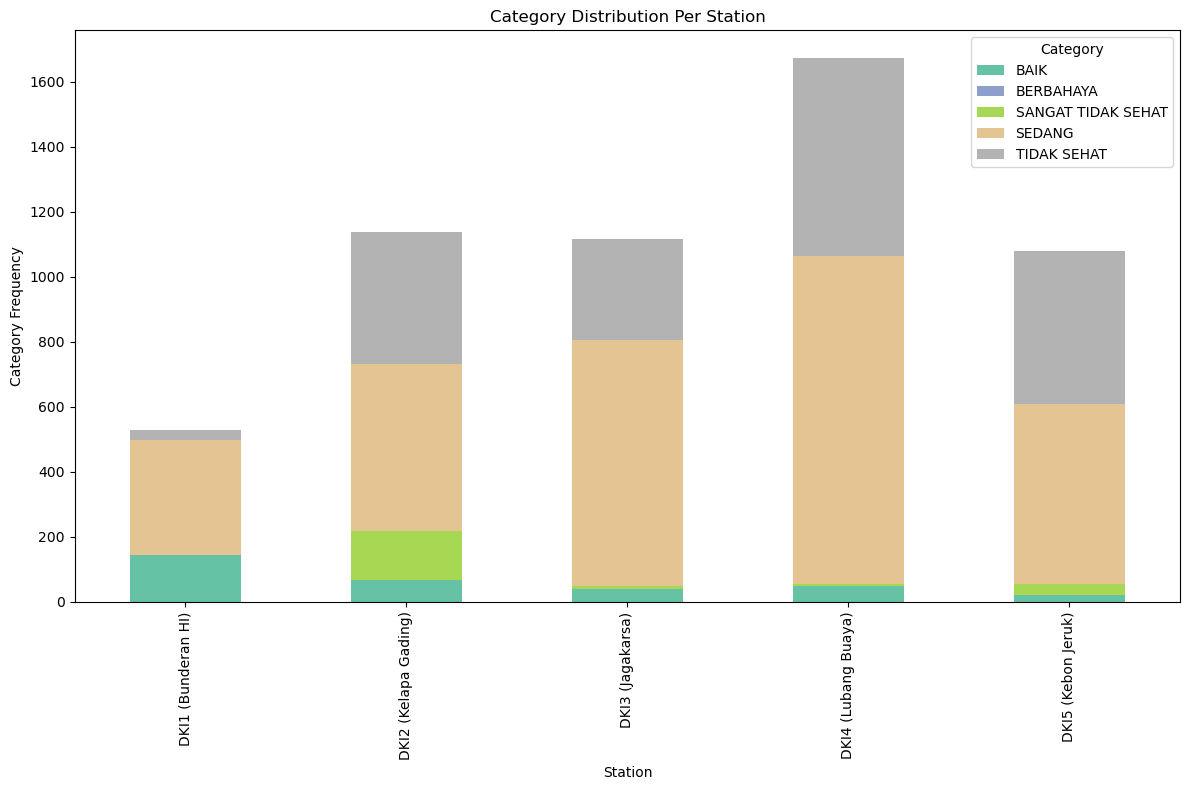

In [240]:
category_per_station = df.groupby(['stasiun', 'categori']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
category_per_station.plot(kind='bar', stacked=True, figsize=(12,8), colormap='Set2')

plt.title('Category Distribution Per Station')
plt.xlabel('Station')
plt.ylabel('Category Frequency')
plt.xticks(rotation=90)
plt.legend(title='Category')
plt.tight_layout()

plt.show()

#### Average Air Pollution by Station

In [241]:
cleaned_data = df[['stasiun', 'pm25', 'pm10', 'so2', 'co', 'o3', 'no2']].dropna()

average_pollutants_per_station = cleaned_data.groupby('stasiun')[['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']].mean()

average_pollutants_per_station

,pm25,pm10,so2,co,o3,no2
stasiun,,,,,,
DKI1 (Bunderan HI),66.174603,42.746032,44.619048,12.984127,18.809524,31.650794
DKI2 (Kelapa Gading),73.773810,52.553571,48.946429,13.839286,43.696429,22.648810
DKI3 (Jagakarsa),70.836735,47.734694,41.301020,12.091837,23.596939,27.438776
DKI4 (Lubang Buaya),97.820122,63.047256,40.844512,16.042683,36.852134,22.027439
DKI5 (Kebon Jeruk),90.858757,49.559322,32.694915,19.824859,47.192090,20.446328


#### Correlation Between Pollutants

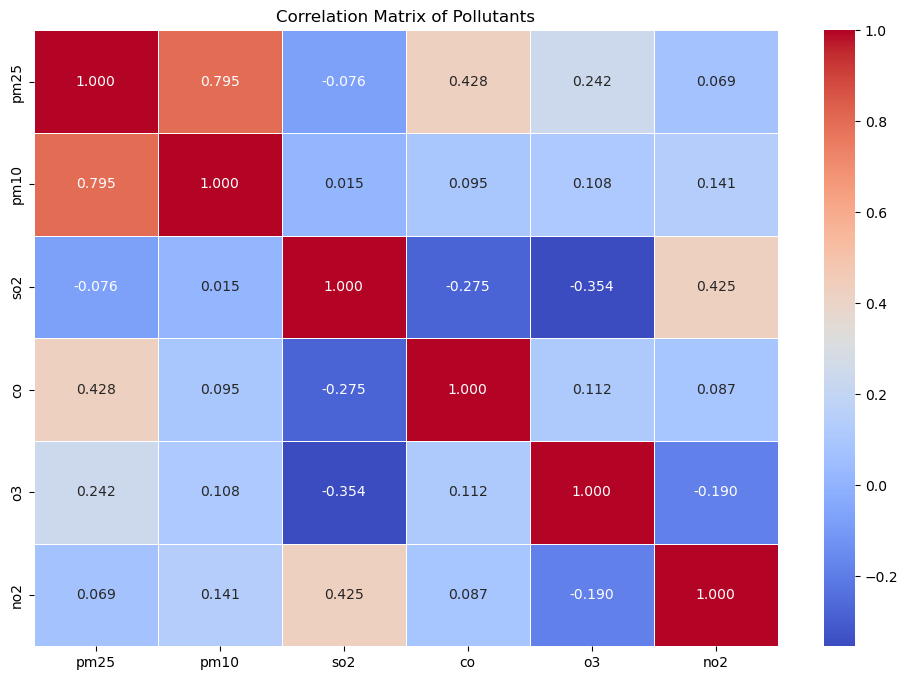

In [242]:
correlation_matrix = df[['pm25', 'pm10', 'so2', 'co', 'o3', 'no2']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title("Correlation Matrix of Pollutants")
plt.show()

###### Notes: The correlation matrix shows a red color for positive correlation (variables increase together) and a blue color for negative correlation (one variable increases while the other decreases).

### Feature Engineering

In [243]:
df["gas_total"] = df[['so2', 'co', 'o3', 'no2']].sum(axis=1)
df["pm10_co_ratio"] = df['pm10'] / (df['co'] + 0.01)
df["avg_pollutant"] = df[['pm10', 'so2', 'co', 'o3', 'no2']].mean(axis=1)

### Check Outliers

<Axes: >

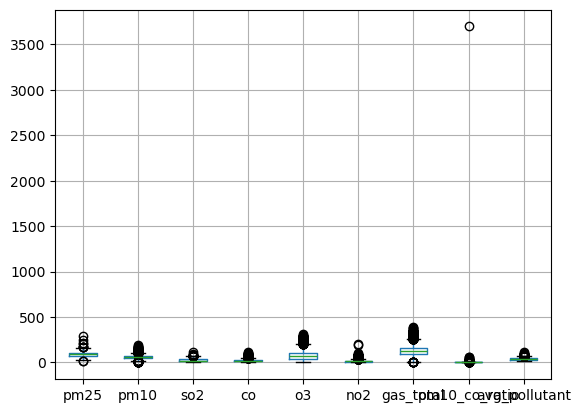

In [244]:
Numerical = ["pm25", "pm10", "so2", "co", "o3", "no2", "gas_total", "pm10_co_ratio", "avg_pollutant"]

df.boxplot(Numerical)

### Check the Distribution of the Numerical Column

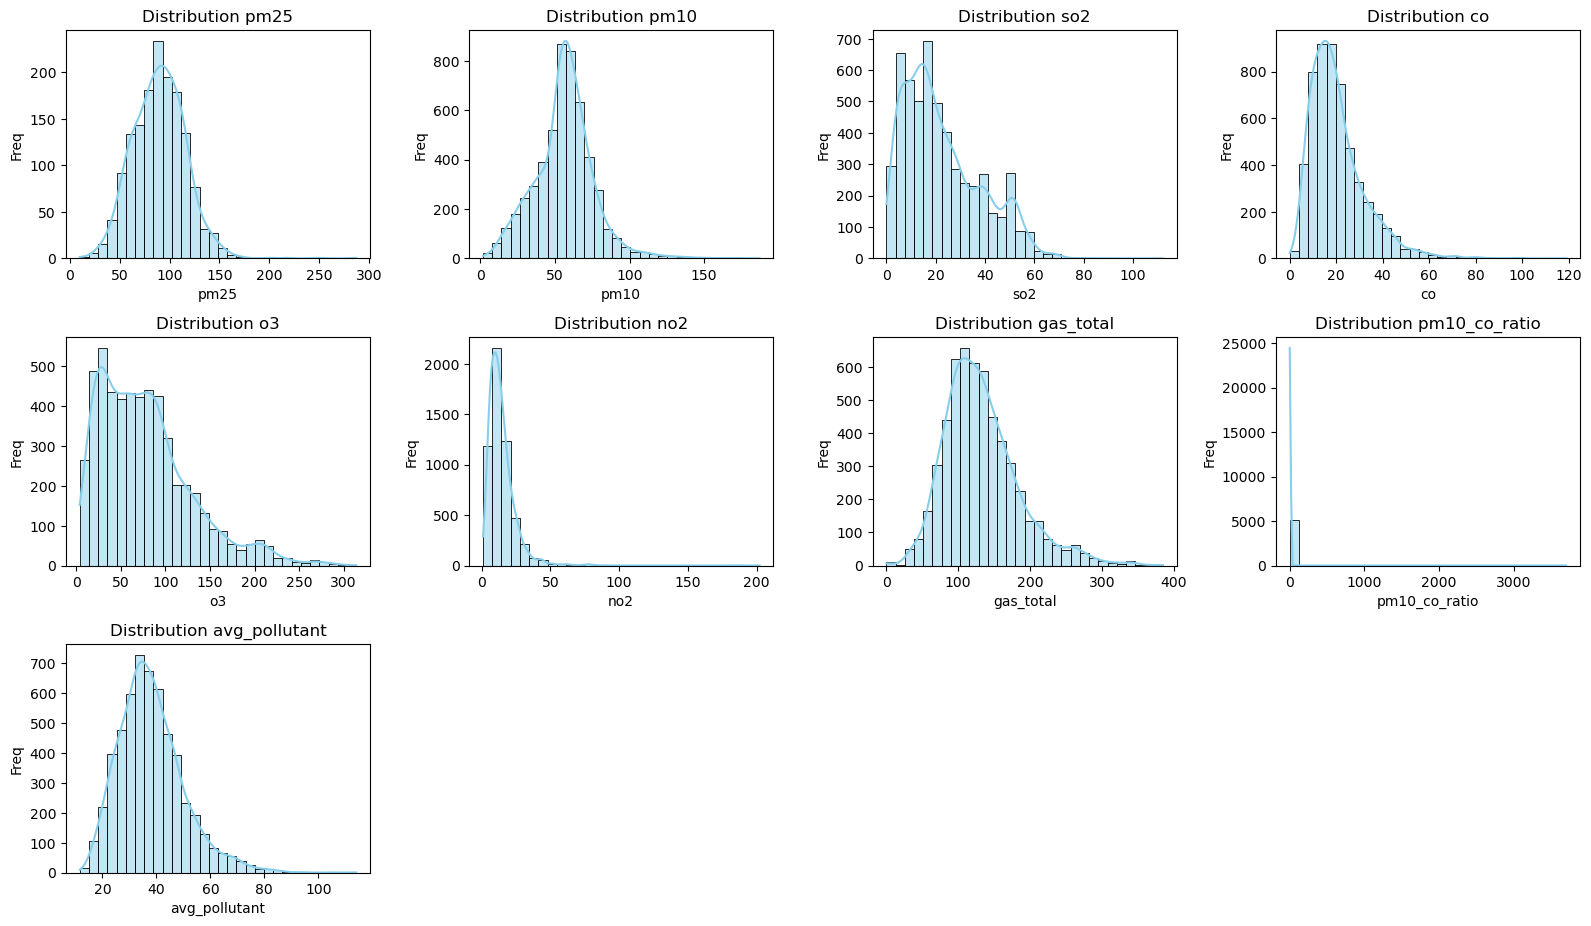

In [245]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(Numerical, 1):
    plt.subplot(4, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution {col}')
    plt.xlabel(col) 
    plt.ylabel('Freq')

plt.tight_layout()

plt.show()


### Check Proportion

In [246]:
#Proportion,<1% = drop na (small dataset), >30% = drop col
(df.isna().sum() / len(df)) * 100

stasiun           0.018070
pm25             72.605710
pm10              5.619805
so2               2.276834
co                1.517889
o3                1.807011
no2               1.843151
categori          0.000000
gas_total         0.000000
pm10_co_ratio     7.065414
avg_pollutant     0.000000
dtype: float64

In [247]:
df = df.drop("pm25", axis= 1)

### Split Data

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5534 entries, 0 to 5537
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   stasiun        5533 non-null   object 
 1   pm10           5223 non-null   float64
 2   so2            5408 non-null   float64
 3   co             5450 non-null   float64
 4   o3             5434 non-null   float64
 5   no2            5432 non-null   float64
 6   categori       5534 non-null   object 
 7   gas_total      5534 non-null   float64
 8   pm10_co_ratio  5143 non-null   float64
 9   avg_pollutant  5534 non-null   float64
dtypes: float64(8), object(2)
memory usage: 475.6+ KB


In [249]:
df = df[df["categori"] != "BERBAHAYA"]

In [250]:
x = df.drop("categori", axis= 1)
y = df["categori"]

x_train, x_test, y_train, y_test, = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [251]:
print("x_train size", x_train.shape[0])
print("x_test size", x_test.shape[0])
print("y_train size", y_train.shape[0])
print("y_test size", y_test.shape[0])

x_train size 4426
x_test size 1107
y_train size 4426
y_test size 1107


In [252]:
y.unique()

array(['SEDANG', 'BAIK', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT'],
      dtype=object)

#### Encoding Variable Y/target

In [253]:
Order = {"BAIK": 0,
         "SEDANG" : 1,
         "TIDAK SEHAT": 2,
         "SANGAT TIDAK SEHAT": 3}

y_train = y_train.map(Order)
y_test = y_test.map(Order)

In [254]:
Numerical = ["pm10", "so2", "co", "o3", "no2", "gas_total", "pm10_co_ratio", "avg_pollutant"]

cat_transformer = Pipeline(steps=[
    ("input", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown= "ignore"))
])

num_transfromer = Pipeline(steps=[
    ("input", SimpleImputer(strategy="median")),
    ("transform", FunctionTransformer(np.log1p, validate= True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, ["stasiun"]),
        ("num", num_transfromer, Numerical)
    ]
)

In [255]:
pca = PCA(n_components= 0.95)

### Logistic Regression Baseline

In [256]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("pca", pca),
    ("model", LogisticRegression(max_iter=100, class_weight='balanced')) #-> to handle imbalanced data
])

In [257]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('input',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['stasiun']),
                                                 ('num',
                                                  Pipeline(steps=[('input',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                       validate=True))]),
                                                  ['pm10', 'so2', 'co', 'o3',
                                                   'no2', 'gas_total',
                                                   'pm10_co_ratio',
                                                   'avg_pollutant'])])),
                ('pca', PCA(n_components=0.95)),
                ('model', LogisticRegression(class_weight='balanced'))])

In [258]:
y_pred = pipeline.predict(x_test)
print("accuracy_score : ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

accuracy_score :  0.6567299006323396
              precision    recall  f1-score   support

           0       0.40      0.79      0.53        78
           1       0.81      0.58      0.68       638
           2       0.59      0.72      0.65       351
           3       0.59      1.00      0.74        40

    accuracy                           0.66      1107
   macro avg       0.60      0.77      0.65      1107
weighted avg       0.71      0.66      0.66      1107



In [259]:
y_pred_prob = pipeline.predict_proba(x_test)

#Multiclass
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')
print("ROC AUC Score: ", roc_auc)

ROC AUC Score:  0.8878833102623596


#### Confusion Matrix

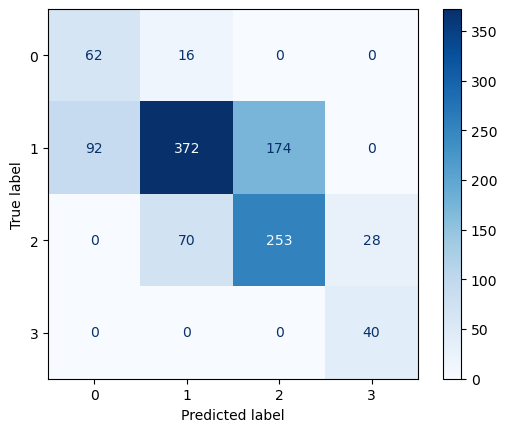

In [260]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')

### Logistic Regression Tuned

In [261]:
param_grid = [

    {
        'model__solver': ['liblinear'],
        'model__penalty': ['l1'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': ['balanced'],
        'model__max_iter': [100, 200, 300],
        'model__multi_class': ['ovr'] 
    },
    {
        'model__solver': ['lbfgs', 'saga', 'newton-cg'],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__class_weight': ['balanced'],
        'model__max_iter': [100, 200, 300],
        'model__multi_class': ['ovr', 'multinomial'] 
    }
]

In [262]:
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('input',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encode',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['stasiun']),
                                                                        ('num',
                                                                         Pipeline(steps=[('input',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('transform',
                                                                                          FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                                              val...
                          'model__max_iter': [100, 200, 300],
                          'model__multi_class': ['ovr'],
                          'model__penalty': ['l1'],
                          'model__solver': ['liblinear']},
                         {'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
                          'model__class_weight': ['balanced'],
                          'model__max_iter': [100, 200, 300],
                          'model__multi_class': ['ovr', 'multinomial'],
                          'model__penalty': ['l2'],
                          'model__solver': ['lbfgs', 'saga', 'newton-cg']}],
             scoring='accuracy')

In [263]:
grid.best_params_

{'model__C': 0.1,
 'model__class_weight': 'balanced',
 'model__max_iter': 100,
 'model__multi_class': 'ovr',
 'model__penalty': 'l1',
 'model__solver': 'liblinear'}

In [264]:
best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(x_test)
y_pred_prob_tuned = best_model.predict_proba(x_test)

print("accuracy_score : ", accuracy_score(y_test,y_pred_tuned))
print(classification_report(y_test,y_pred_tuned))

roc_auc_tuned = roc_auc_score(y_test, y_pred_prob_tuned, multi_class='ovr', average='macro')
print("ROC AUC Score: ", roc_auc_tuned)

accuracy_score :  0.7289972899728997
              precision    recall  f1-score   support

           0       0.55      0.62      0.58        78
           1       0.79      0.77      0.78       638
           2       0.67      0.67      0.67       351
           3       0.74      0.85      0.79        40

    accuracy                           0.73      1107
   macro avg       0.69      0.73      0.71      1107
weighted avg       0.73      0.73      0.73      1107

ROC AUC Score:  0.8926431713880238


#### Confusion Matrix

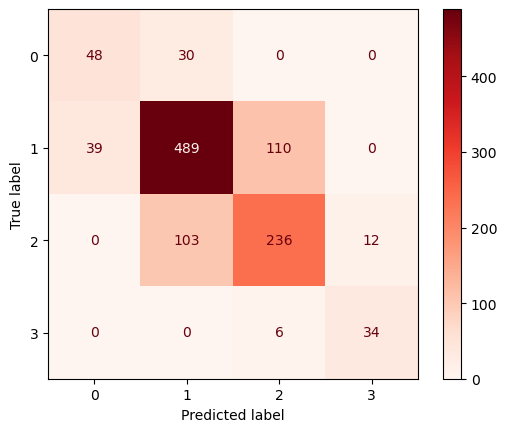

In [265]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned, cmap='Reds')

##### Compare

In [266]:
print("--BASELINE--")
print("accuracy_score : ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("ROC AUC Score: ", roc_auc)

print("\n\n")

print("--TUNED--")
print("accuracy_score : ", accuracy_score(y_test,y_pred_tuned))
print(classification_report(y_test,y_pred_tuned))
print("ROC AUC Score: ", roc_auc_tuned)

--BASELINE--
accuracy_score :  0.6567299006323396
              precision    recall  f1-score   support

           0       0.40      0.79      0.53        78
           1       0.81      0.58      0.68       638
           2       0.59      0.72      0.65       351
           3       0.59      1.00      0.74        40

    accuracy                           0.66      1107
   macro avg       0.60      0.77      0.65      1107
weighted avg       0.71      0.66      0.66      1107

ROC AUC Score:  0.8878833102623596



--TUNED--
accuracy_score :  0.7289972899728997
              precision    recall  f1-score   support

           0       0.55      0.62      0.58        78
           1       0.79      0.77      0.78       638
           2       0.67      0.67      0.67       351
           3       0.74      0.85      0.79        40

    accuracy                           0.73      1107
   macro avg       0.69      0.73      0.71      1107
weighted avg       0.73      0.73      0.73      1

###### Notes: The F1-score is used as our primary metric to balance the trade-off between precision and recall.

##### The tuned model demonstrates a significant performance breakthrough compared to the baseline, notably increasing the overall accuracy from 65.7% to 72.9% and raising the Macro F1-score to 0.71. This improvement confirms that the combination of hyperparameter tuning and feature engineering successfully optimized the classifier's ability to handle imbalanced data, resulting in a more robust and reliable model for all air quality categories.

### Evaluating Model Stability and Overfitting Using Learning Curves

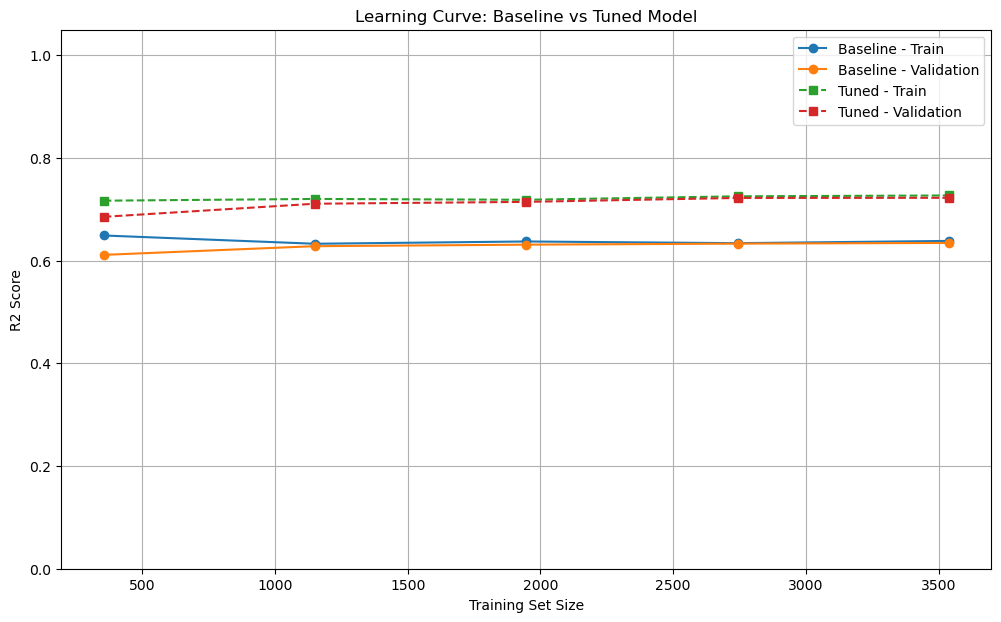

In [267]:
# Baseline model
baseline_model = pipeline

# Tuned model
tuned_model = best_model

train_sizes = np.linspace(0.1, 1.0, 5)

# Baseline learning curve
train_sizes_b, train_scores_b, val_scores_b = learning_curve(
    baseline_model, x_train, y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Tuned learning curve
train_sizes_t, train_scores_t, val_scores_t = learning_curve(
    tuned_model, x_train, y_train,
    train_sizes=train_sizes,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean_b = train_scores_b.mean(axis=1)
val_mean_b = val_scores_b.mean(axis=1)

train_mean_t = train_scores_t.mean(axis=1)
val_mean_t = val_scores_t.mean(axis=1)

plt.figure(figsize=(12, 7))

plt.plot(train_sizes_b, train_mean_b, marker="o", label="Baseline - Train")
plt.plot(train_sizes_b, val_mean_b, marker="o", label="Baseline - Validation")

plt.plot(train_sizes_t, train_mean_t, marker="s", linestyle="--", label="Tuned - Train")
plt.plot(train_sizes_t, val_mean_t, marker="s", linestyle="--", label="Tuned - Validation")

plt.ylim(0, 1.05) 

plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve: Baseline vs Tuned Model")
plt.legend()
plt.grid(True)
plt.show()

##### The learning curves indicate a healthy and robust model with no signs of overfitting, as evidenced by the minimal gap between the training and validation scores across both baseline and tuned versions. The tuned model shows a significant performance breakthrough, effectively shifting the $R^2$ score plateau from approximately 0.6 to over 0.7. This tight convergence of curves at a higher performance level confirms that the model generalizes exceptionally well to unseen data and has successfully extracted more predictive value through optimization.

#### Save Model

In [268]:
import joblib

joblib.dump(best_model, 'Air_Quality_model(logistic_linear).pkl')

print("The model has been successfully saved as: Air_Quality_model(logistic_linear).pkl")

The model has been successfully saved as: Air_Quality_model(logistic_linear).pkl
